*Project Overview*

This project focuses on exploratory data analysis (EDA) to understand the structure,quality, and patterns present in a real-world dataset.

The analysis will include data inspection,data-quality checks,descriptive statistics, missing-value analysis,duplicate detection,outlier identification,and exploration of relationship between important variables.

The goal is to understand the dataset before moving toward deeper analysis and visualization.


## 1. Questions to Explore

Before analyzing the dataset, the following questions will be investigated:

1. What are the main characteristics of the customers and their shopping behavior?

2. Which product categories are the most frequently purchased?

3. How does the purchase amount vary across different product categories?

4. Is there any relationship between customer age and purchase amount?

5. Do customer ratings differ across product categories?

6. Are certain payment methods or shopping preferences more common among customers?

7. Are there any unusual values, missing values, duplicate records, or other data-quality issues that could affect the analysis?

8. Can statistical analysis provide evidence for any relationship between important variables in the dataset?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("/content/shopping_trends.csv")

In [10]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [11]:
df.shape

(3900, 19)

In [12]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [13]:
df.info

<bound method DataFrame.info of       Customer ID  Age  Gender Item Purchased     Category  \
0               1   55    Male         Blouse     Clothing   
1               2   19    Male        Sweater     Clothing   
2               3   50    Male          Jeans     Clothing   
3               4   21    Male        Sandals     Footwear   
4               5   45    Male         Blouse     Clothing   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     Clothing   
3896         3897   52  Female       Backpack  Accessories   
3897         3898   46  Female           Belt  Accessories   
3898         3899   44  Female          Shoes     Footwear   
3899         3900   52  Female        Handbag  Accessories   

      Purchase Amount (USD)       Location Size      Color  Season  \
0                        53       Kentucky    L       Gray  Winter   
1                        64          Maine    L     Maroon  Winter   
2                        73  Massachusetts    S     Maroon  Spring   
3                        90   Rhode Island    M     Maroon  Spring   
4                        49         Oregon    M  Turquoise  Spring   
...                     ...            ...  ...        ...     ...   
3895                     28       Virginia    L  Turquoise  Summer   
3896                     49           Iowa    L      White  Spring   
3897                     33     New Jersey    L      Green  Spring   
3898                     77      Minnesota    S      Brown  Summer   
3899                     81     California    M      Beige  Spring   

      Review Rating Subscription Status Payment Method   Shipping Type  \
0               3.1                 Yes    Credit Card         Express   
1               3.1                 Yes  Bank Transfer         Express   
2               3.1                 Yes           Cash   Free Shipping   
3               3.5                 Yes         PayPal    Next Day Air   
4               2.7                 Yes           Cash   Free Shipping   
...             ...                 ...            ...             ...   
3895            4.2                  No           Cash  2-Day Shipping   
3896            4.5                  No         PayPal    Store Pickup   
3897            2.9                  No    Credit Card        Standard   
3898            3.8                  No         PayPal         Express   
3899            3.1                  No  Bank Transfer    Store Pickup   

     Discount Applied Promo Code Used  Previous Purchases  \
0                 Yes             Yes                  14   
1                 Yes             Yes                   2   
2                 Yes             Yes                  23   
3                 Yes             Yes                  49   
4                 Yes             Yes                  31   
...               ...             ...                 ...   
3895               No              No                  32   
3896               No              No                  41   
3897               No              No                  24   
3898               No              No                  24   
3899               No              No                  33   

     Preferred Payment Method Frequency of Purchases  
0                       Venmo            Fortnightly  
1                        Cash            Fortnightly  
2                 Credit Card                 Weekly  
3                      PayPal                 Weekly  
4                      PayPal               Annually  
...                       ...                    ...  
3895                    Venmo                 Weekly  
3896            Bank Transfer              Bi-Weekly  
3897                    Venmo              Quarterly  
3898                    Venmo                 Weekly  
3899                    Venmo              Quarterly  

[3900 rows x 19 columns]>

In [14]:
df.dtypes


,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


### Variable Classification

The dataset contains the following types of variables:

**Numerical Variables**
- Customer ID
- Age
- Purchase Amount (USD)
- Review Rating
- Previous Purchases

**Categorical Variables**
- Gender
- Item Purchased
- Category
- Location
- Size
- Color
- Season
- Subscription Status
- Payment Method
- Shipping Type
- Discount Applied
- Promo Code Used
- Preferred Payment Method
- Frequency of Purchases

Customer ID is treated as an identifier rather than a variable for statistical analysis.

In [15]:
missing_values = df.isnull().sum()
print(missing_values)

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64


In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

Customer ID                 0.0
Age                         0.0
Gender                      0.0
Item Purchased              0.0
Category                    0.0
Purchase Amount (USD)       0.0
Location                    0.0
Size                        0.0
Color                       0.0
Season                      0.0
Review Rating               0.0
Subscription Status         0.0
Payment Method              0.0
Shipping Type               0.0
Discount Applied            0.0
Promo Code Used             0.0
Previous Purchases          0.0
Preferred Payment Method    0.0
Frequency of Purchases      0.0
dtype: float64


### Missing Value Finding

The missing-value analysis shows that there are no missing values in any column of the dataset. Therefore, no missing-value treatment is required at this stage.

In [17]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


### Duplicate Value Finding

The duplicate-value check identified 0 duplicate rows in the dataset. Therefore, no duplicate records need to be removed at this stage.

In [18]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


Descriptive Statistics Findings
The dataset contains 3,900 customer records. The average customer age is approximately 44 years, while the average purchase amount is about 59.76 USD. The average review rating is approximately 3.75, indicating generally moderate-to-positive ratings. Previous purchases range from 1 to 50, with an average of approximately 25 purchases. The numerical variables will be explored further to identify distributions, patterns, and potential anomalies.

In [19]:
df.select_dtypes(include=['object']).nunique()

,0
Gender,2
Item Purchased,25
Category,4
Location,50
Size,4
Color,25
Season,4
Subscription Status,2
Payment Method,6
Shipping Type,6


Categorical Variable Analysis

The dataset contains several categorical variables with different numbers of unique values. Gender, subscription status, discount applied, and promo code used contain two categories, while variables such as item purchased, location, color, payment method, and purchase frequency contain multiple categories. These variables will be explored further to identify customer preferences, purchasing patterns, and differences between groups.

In [20]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


Missing Value Analysis

The missing-value analysis shows that all columns contain zero missing values. Therefore, the dataset does not require any missing-value imputation or removal at this stage. This indicates that the available records are complete with respect to the variables included in the dataset.

In [21]:
df.duplicated().sum()

np.int64(0)

Duplicate Record Analysis

The dataset contains 0 duplicate records. This indicates that no exact duplicate rows were identified during the data-quality check. Therefore, no duplicate records need to be removed at this stage.

In [22]:
df[["Age", "Purchase Amount (USD)","Review Rating","Previous Purchases"]].describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [23]:
numeric_cols = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"{col}")
    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)
    print("Number of outliers:", len(outliers))
    print("-" * 40)

Age
Lower limit: -8.0
Upper limit: 96.0
Number of outliers: 0
----------------------------------------
Purchase Amount (USD)
Lower limit: -24.0
Upper limit: 144.0
Number of outliers: 0
----------------------------------------
Review Rating
Lower limit: 1.1499999999999997
Upper limit: 6.3500000000000005
Number of outliers: 0
----------------------------------------
Previous Purchases
Lower limit: -24.5
Upper limit: 75.5
Number of outliers: 0
----------------------------------------


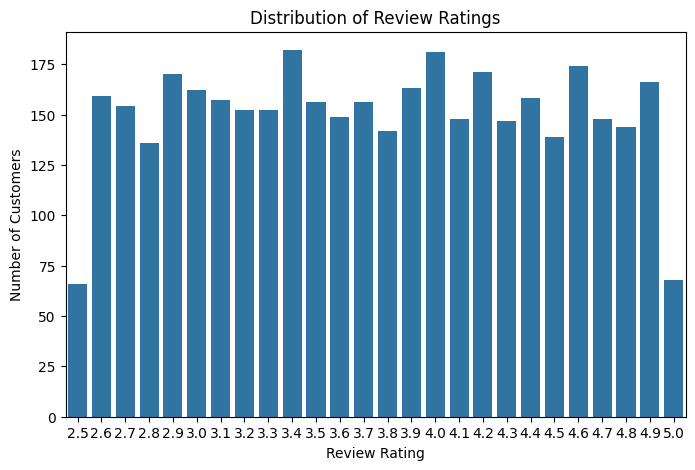

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Review Rating")

plt.title("Distribution of Review Ratings")
plt.xlabel("Review Rating")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
category_purchase = df.groupby("Category")["Purchase Amount (USD)"].mean().sort_values(ascending=False)
print(category_purchase)

Category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64


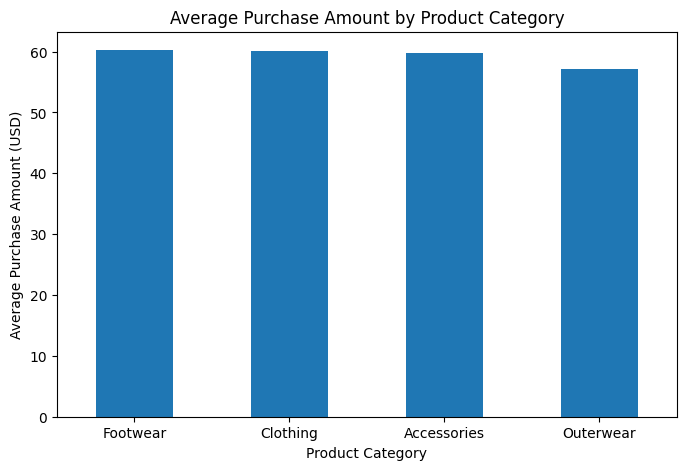

In [26]:
plt.figure(figsize=(8,5))

category_purchase.plot(kind="bar")

plt.title("Average Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.show()

In [27]:
age_purchase_corr = df["Age"].corr(df["Purchase Amount (USD)"])
print("Correlation between age and purchase amount:", age_purchase_corr)

Correlation between age and purchase amount: -0.01042364737868652


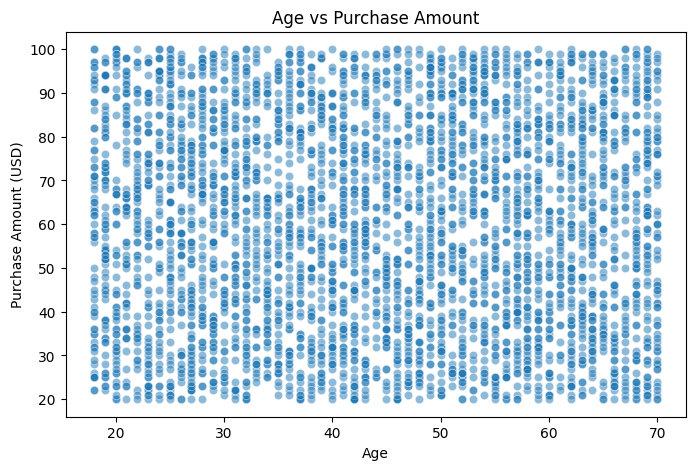

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Purchase Amount (USD)",
    alpha=0.5
)

plt.title("Age vs Purchase Amount")
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")

plt.show()

In [29]:
category_rating = df.groupby("Category")["Review Rating"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

print(category_rating)

             count      mean  median
Category                            
Footwear       599  3.790651     3.8
Accessories   1240  3.768629     3.8
Outerwear      324  3.746914     3.8
Clothing      1737  3.723143     3.7


In [30]:
payment_counts = df["Payment Method"].value_counts()
print(payment_counts)

Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64


In [31]:
preference_counts = df["Preferred Payment Method"].value_counts()
print(preference_counts)


Preferred Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


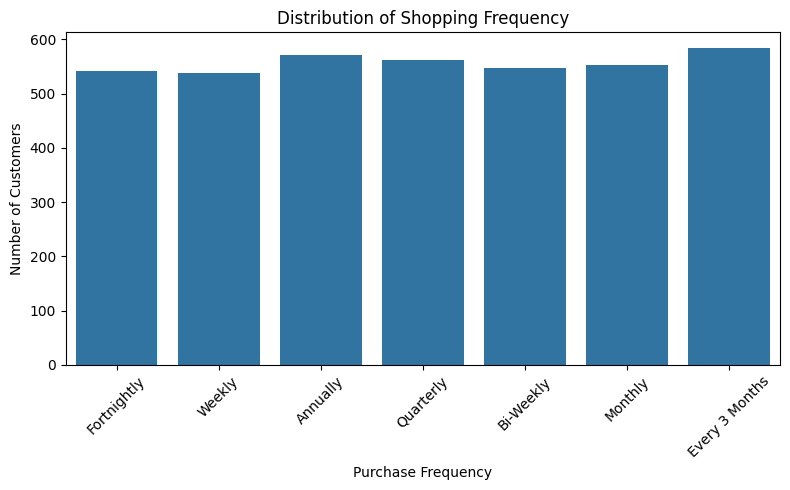

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Frequency of Purchases"
)

plt.title("Distribution of Shopping Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
print("missing values:")
print(df.isnull().sum())
print("\nduplicate values:")
print(df.duplicated().sum())


missing values:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

duplicate values:
0


In [34]:
# Checking outliers using IQR method

numerical_columns = ["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(column)
    print("Number of outliers:", len(outliers))
    print("-" * 40)

Age
Number of outliers: 0
----------------------------------------
Purchase Amount (USD)
Number of outliers: 0
----------------------------------------
Review Rating
Number of outliers: 0
----------------------------------------
Previous Purchases
Number of outliers: 0
----------------------------------------


In [35]:
from scipy.stats import pearsonr

data = df[["Age", "Purchase Amount (USD)"]].dropna()

correlation, p_value = pearsonr(
    data["Age"],
    data["Purchase Amount (USD)"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: -0.010423647378686533
P-value: 0.515197824122489


## Key Findings

After exploring the dataset, I found the following observations:

• The dataset contains information about customers, their purchases, product categories, ratings, payment methods and shopping frequency.

• The number of purchases is different for different product categories.

• The average purchase amount also varies across product categories.

• The review ratings are distributed across different rating values.

• Credit Card is the most commonly used payment method in the dataset.

• There are no missing values in the dataset.

• There are no duplicate records in the dataset.

• No outliers were found in Age, Purchase Amount, Review Rating and Previous Purchases using the IQR method.

• The correlation between Age and Purchase Amount is -0.0104, which shows that the relationship between these two variables is very weak.

• The p-value is 0.5152, which is greater than 0.05. Therefore, the analysis does not show a statistically significant linear relationship between Age and Purchase Amount.

## Conclusion

Through this EDA, I was able to understand the main characteristics of the customers and their shopping behavior. I also checked the quality of the data by looking for missing values, duplicate records and outliers. The analysis of categories, purchase amounts, ratings and payment methods helped me understand the different patterns present in the dataset. These findings can be used for further analysis and visualization of customer shopping behavior.

In [36]:
# Correlation analysis between numerical variables

numeric_columns = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)

                            Age  Purchase Amount (USD)  Review Rating  \
Age                    1.000000              -0.010424      -0.021949   
Purchase Amount (USD) -0.010424               1.000000       0.030776   
Review Rating         -0.021949               0.030776       1.000000   
Previous Purchases     0.040445               0.008063       0.004229   

                       Previous Purchases  
Age                              0.040445  
Purchase Amount (USD)            0.008063  
Review Rating                    0.004229  
Previous Purchases               1.000000  


The correlation analysis shows that there is almost no linear relationship between Age and Purchase Amount, with a correlation of approximately -0.01. Purchase Amount and Review Rating also show a very weak positive relationship of about 0.03. Previous Purchases have very weak correlations with the other numerical variables. Overall, the relationships between these variables appear to be negligible in this dataset.

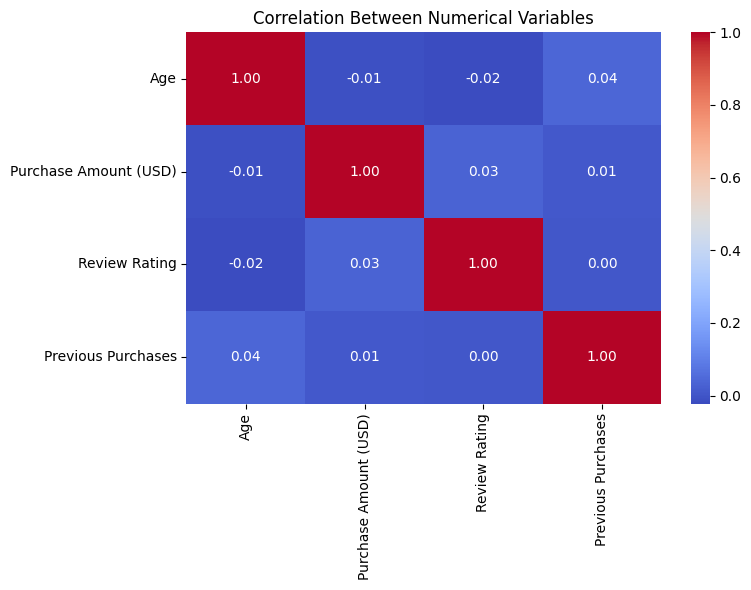

In [37]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

The correlation heatmap shows that most numerical variables have very weak relationships with each other. Age and Purchase Amount have a correlation of approximately -0.01, while Purchase Amount and Review Rating have a correlation of about 0.03. Previous Purchases also show very weak correlations with the other variables. Overall, no strong linear relationship is observed among the numerical variables.

## Key Findings from EDA
- The dataset contains customer shopping information across different product categories.
- Clothing has the highest number of records among the observed product categories.
- The average purchase amount is relatively similar across the product categories.
- Age and purchase amount show almost no linear correlation.
- Review ratings are distributed across a broad range of values.
- Payment methods are relatively distributed across the available options.
- No major outliers were detected in the numerical variables examined.
- The correlation analysis shows very weak relationships among the main numerical variables.

## EDA CONCLUSION
The exploratory data analysis provided an overall understanding of the customer shopping dataset. The dataset contains information related to customer demographics, product categories, purchase amounts, review ratings, payment methods, and previous purchases.

The analysis showed that purchase amounts are relatively similar across the different product categories. Age and purchase amount have almost no linear relationship, as indicated by the correlation analysis. The numerical variables also show generally weak correlations with each other.

Missing-value, duplicate, and outlier checks were performed to assess the quality of the dataset. No major issues were identified in the checks performed.

These findings provide a foundation for further analysis, particularly through visualization and deeper investigation of customer shopping patterns.

## Next Steps


The next stage of the project will focus on creating meaningful visualizations and exploring customer shopping patterns in greater detail.